In [682]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Input
from keras.optimizers import Adam

# Churn_Modelling

In [683]:
churn = pd.read_csv('Churn_Modelling.csv')
print(churn.columns)
churn.head()

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [684]:
churn.duplicated().sum()

np.int64(0)

In [685]:
churn.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


we will drop `RowNumber`,`CustomerId`,`Surname` as they nothing to add to the *predictions*

In [686]:
churn = churn.drop(columns=['RowNumber','CustomerId','Surname'])

we have string columns `Geography`,`Gender` so will transform them

In [687]:
churn['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [688]:
# as Geography have 3 unique values only we will you OneHotEncoder
churn = pd.get_dummies(churn, columns=['Geography','Gender'], drop_first=True)

and that's the dataset cleaned

In [689]:
churn.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [690]:
churn.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


here we can see that except `exited`(the Y), `HasCrCard` , `IsActiveMember` all the others need a stander scaler

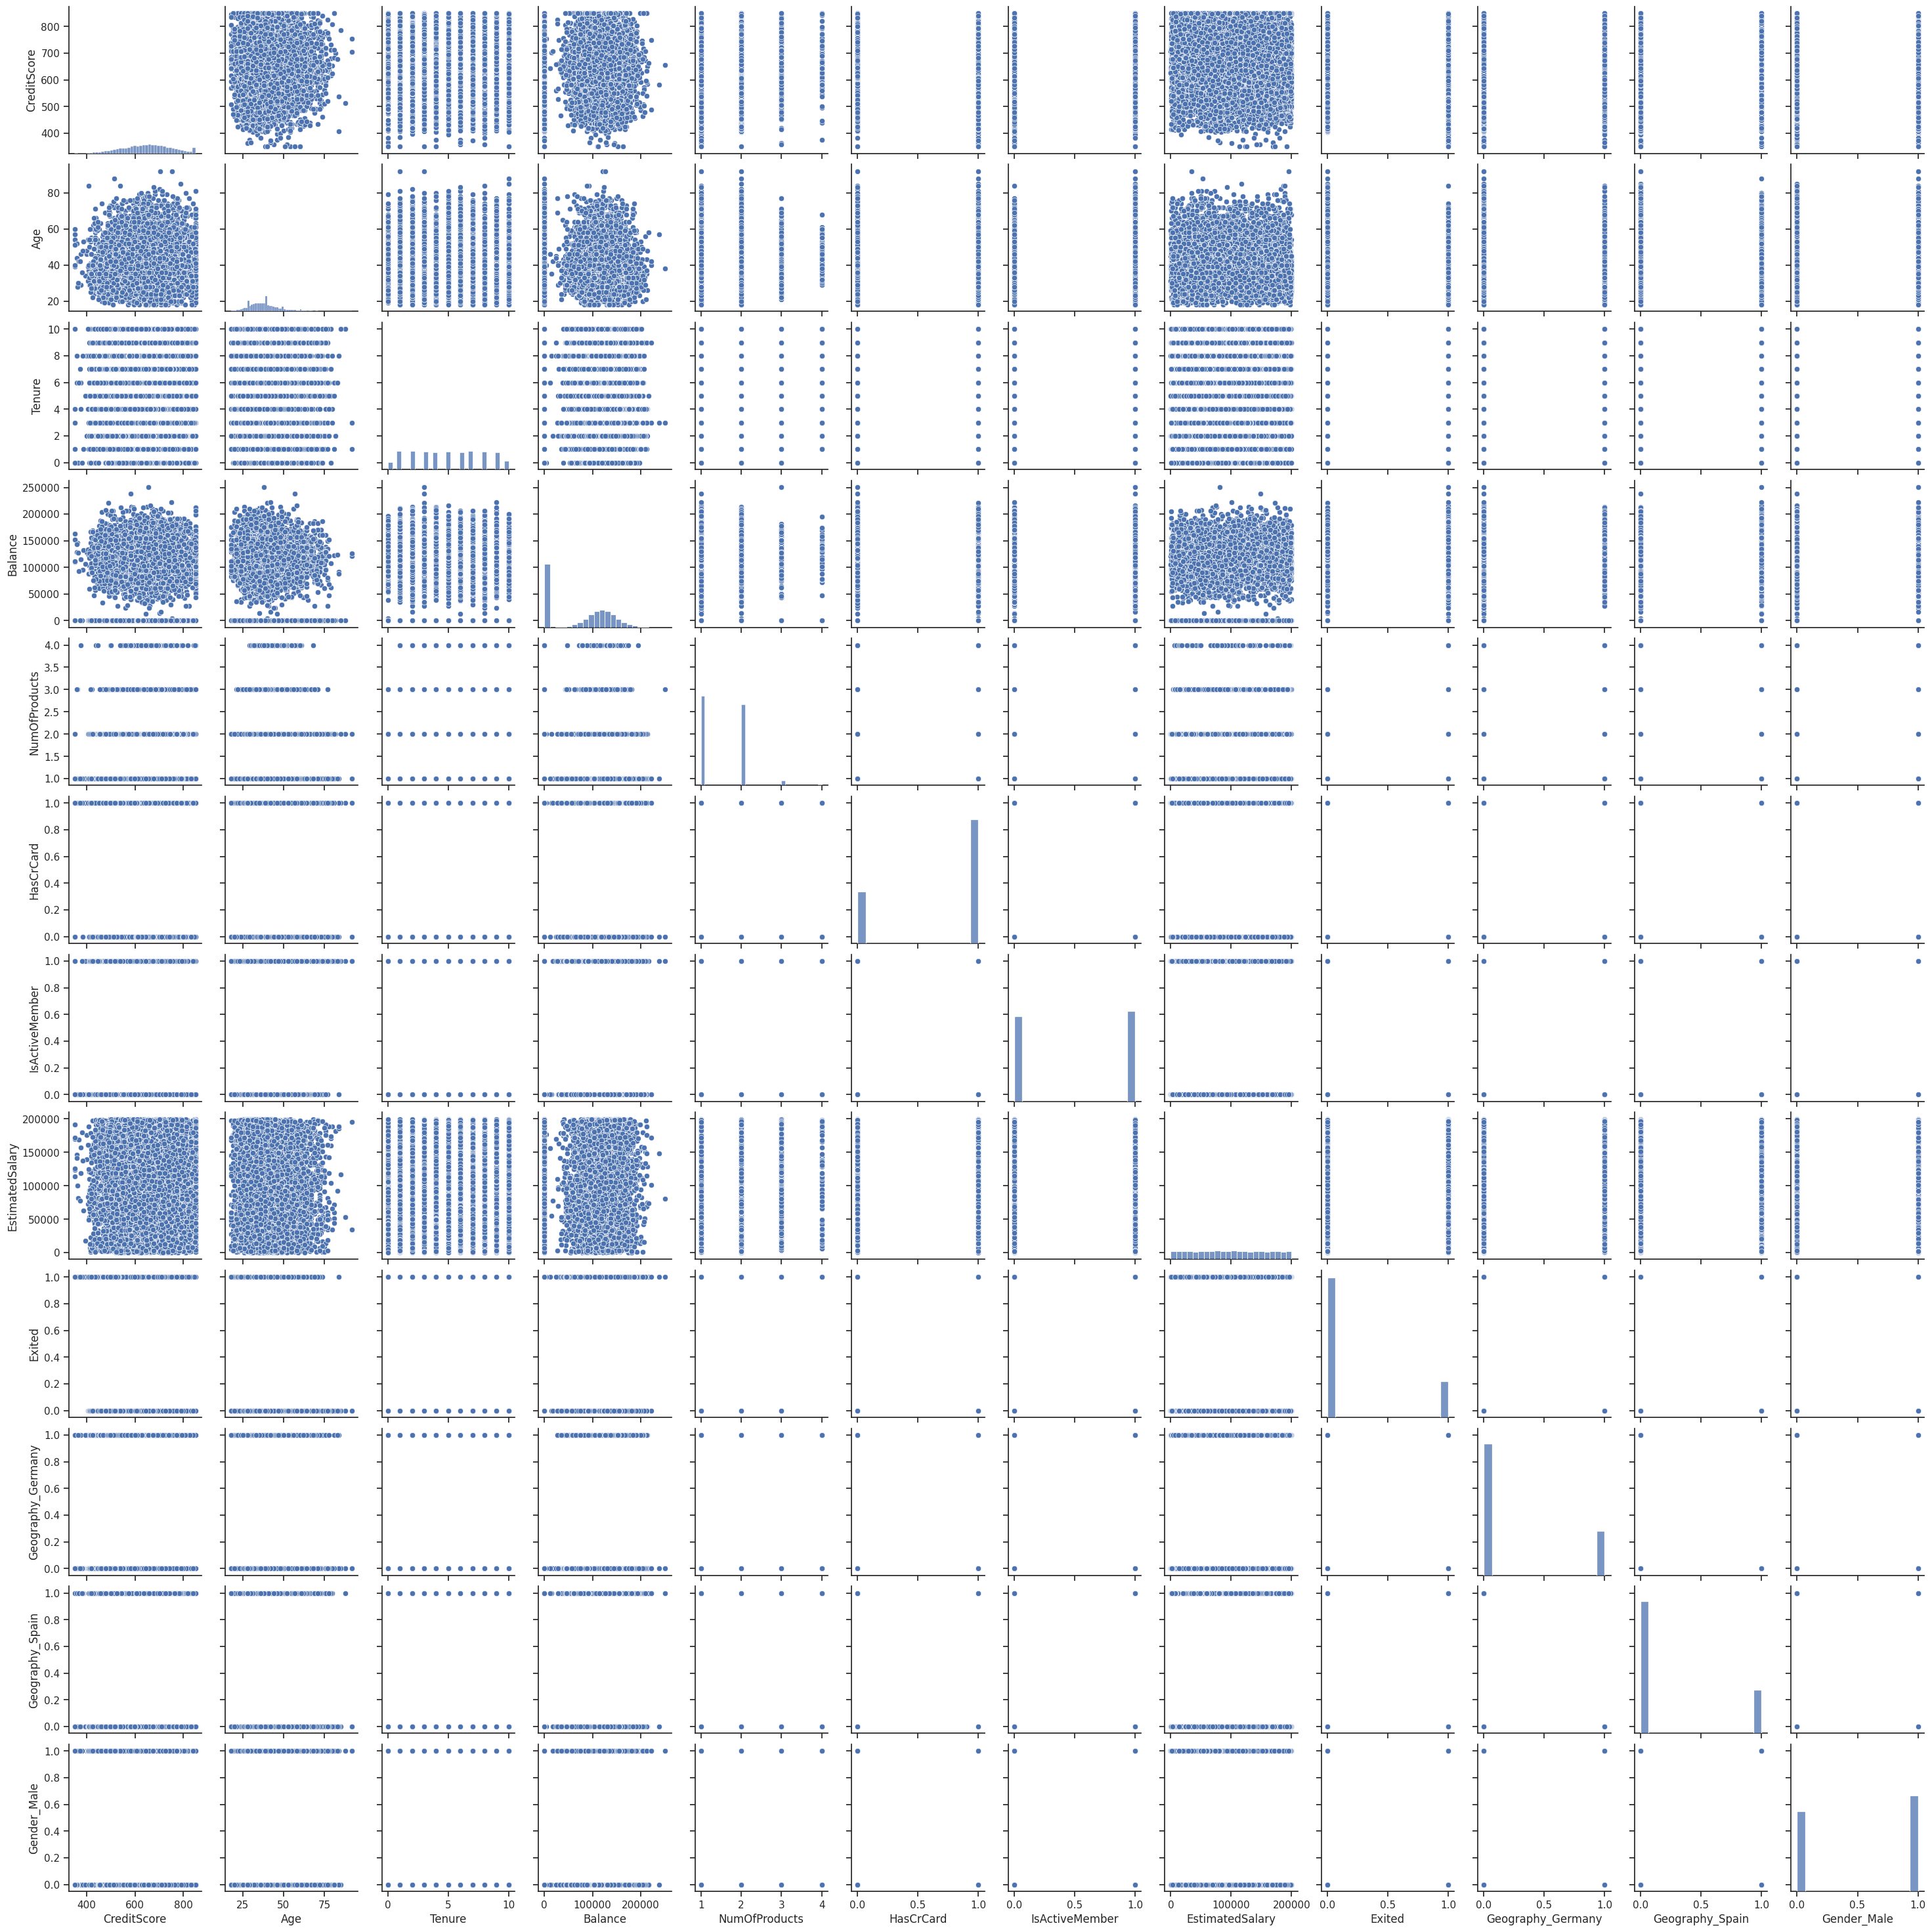

In [691]:
sns.pairplot(churn)

we can see here that there is no specific trend

In [692]:
x = churn.drop(columns='Exited')
y = churn['Exited']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15 ,random_state=23, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15 ,random_state=23, stratify=y_train)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7225, 11)
(1500, 11)
(7225,)
(1500,)


In [693]:
model = Sequential()

model.add(Input(shape=(11,)))
model.add(Dense(24,activation='relu'))
model.add(Dense(12,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [694]:
model.compile(optimizer='adam', loss='binary_crossentropy')

In [695]:
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_val,y_val), verbose=1, batch_size=45)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5192 - val_loss: 0.4531
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4329 - val_loss: 0.4195
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4068 - val_loss: 0.3918
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3843 - val_loss: 0.3674
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3675 - val_loss: 0.3532
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3577 - val_loss: 0.3451
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3518 - val_loss: 0.3413
Epoch 8/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3470 - val_loss: 0.3390
Epoch 9/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3461 - val_loss: 0.3358
Epoch 10/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3431 - val_loss: 0.3364
Epoch 11/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3408 - val_loss: 0.3368
Epoch 12/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [696]:
y_prob = model.predict(x_val)
precisions, recalls, thresholds = precision_recall_curve(y_val,y_prob)
f1 = (2*precisions*recalls)/(precisions+recalls+1e-10)
best_threshold = thresholds[np.argmax(f1)]

y_hat = (model.predict(x_test)>best_threshold).astype(int)
print(f"best threshold is: {best_threshold}")
print(classification_report(y_test, y_hat))
print(confusion_matrix(y_test, y_hat))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
best threshold is: 0.36055928468704224
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1194
           1       0.64      0.61      0.62       306

    accuracy                           0.85      1500
   macro avg       0.77      0.76      0.77      1500
weighted avg       0.85      0.85      0.85      1500

[[1088  106]
 [ 119  187]]
